# Demo: Bounce Action $S_E$

This notebook demonstrates how to compute the Euclidean bounce action $S_E(T, g_D)$ — the tunneling exponent that controls the nucleation rate.

**Pipeline step:** $S_E$ is the third layer. Given an effective potential, the bounce solver finds the $O(3)$-symmetric bounce solution and integrates the action.

**Modules used:** `src/RGE/BounceSolFull_RGE.py`, `src/RGE/BounceSolHighT_RGE.py`

**Two approximations are available:**
- **Full potential** (`BounceSolver`): uses the complete thermal $J_B$ function from the numerical table. More accurate, slower (~1 min/point).
- **High-T expansion** (`BounceSolverHighT`): uses the $m/T \ll 1$ expansion of $J_B$. Valid near the critical temperature, about the same speed but less accurate at low $T$.

**Contents:**
1. Single-curve $S_E(T)$ with the full potential
2. Single-curve $S_E(T)$ with the high-$T$ expansion
3. Generating a $(T, g_D)$ grid and saving to disk

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [2]:
# Instantiate both solvers sharing the same VeffRGE object
veff_obj  = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
solver    = bs_full.BounceSolver(veff=veff_obj)          # full J_B from table
solver_ht = bs_ht.BounceSolverHighT(veff=veff_obj)       # high-T expansion
fopt_obj  = fopt.FOPTUtilities(veff_obj=veff_obj)        # for Hubble parameter


/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/.venv/lib/python3.9/site-packages/scipy/ndimage/_filters.py:1856: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


## 1. Single-curve $S_E(T)$ — full potential

For a fixed $(g_D, \mu/T)$, we sweep $T$ and compute $S_E$. The nucleation condition is:
$$\frac{S_E(T_n)}{T_n} = 4\ln T_n + \frac{3}{2}\ln\frac{S_E/(2\pi T)}{T_n^2} - 4\ln H(T_n)$$
The crossing of $S_E/T$ with this RHS defines the nucleation temperature $T_n$.

> **Note:** Each point takes ~1 min. Reduce `n_T` for a quick test.

In [4]:
gD0   = 0.8
scale = np.pi       # renormalization scale mu = pi * T (evaluated at T)
ls0   = 1e-10
n_T   = 25

T_vals_full = np.logspace(-5, np.log10(0.3), n_T)
S_vals_full = []

for T in tqdm(T_vals_full, desc="Full S_E"):
    try:
        S, _ = solver.SE(T, gD0, scale, ls0)
        S_vals_full.append(S)
    except Exception as e:
        print(f"  Failed at T={T:.3e}: {e}")
        S_vals_full.append(np.nan)

S_full = np.array(S_vals_full, dtype=float)

Full S_E: 100%|██████████| 25/25 [02:01<00:00,  4.86s/it]


In [5]:
# Compute the nucleation condition RHS
H_full  = np.array([
    fopt_obj.hubble(solver.phi_min_Veff0(T, gD0, scale, ls0), T, gD0, scale, ls0)
    for T in T_vals_full
])

ST_full  = S_full / T_vals_full
eps      = 1e-300
nuc_rhs  = (4.0 * np.log(T_vals_full)
            + 1.5 * np.log(np.maximum(ST_full / (2.0 * np.pi), eps))
            - 4.0 * np.log(np.maximum(H_full, eps)))
mask     = np.isfinite(nuc_rhs) & (nuc_rhs > 0) & np.isfinite(ST_full) & (ST_full > 0)

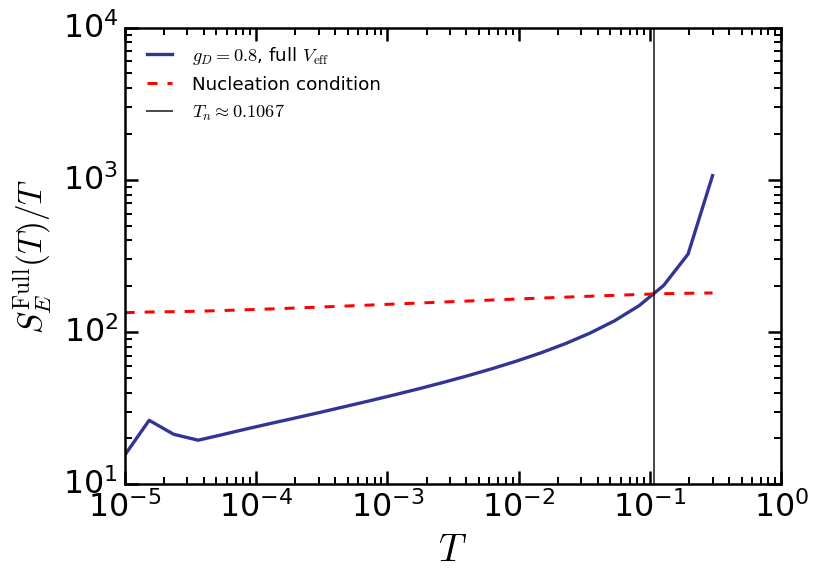

In [6]:
fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')

ax.plot(T_vals_full[np.isfinite(ST_full)], ST_full[np.isfinite(ST_full)],
        color=ps.colors.get("Full", "steelblue"), lw=2, label=fr'$g_D={gD0}$, full $V_{{\rm eff}}$')
ax.plot(T_vals_full[mask], nuc_rhs[mask],
        color='red', ls='--', lw=1.8, label='Nucleation condition')

# Mark nucleation temperature
y_cross = (ST_full - nuc_rhs)[mask]
T_mask  = T_vals_full[mask]
crossings = np.where(np.sign(y_cross[:-1]) * np.sign(y_cross[1:]) < 0)[0]
if crossings.size:
    i  = crossings[0]
    Tn = T_mask[i] - y_cross[i] * (T_mask[i+1] - T_mask[i]) / (y_cross[i+1] - y_cross[i])
    ax.axvline(Tn, color='k', lw=1.2, alpha=0.7, label=fr'$T_n \approx {Tn:.4f}$')

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=True,
    xlabel=r'$T$',
    ylabel=r'$S_E^{\rm Full}(T)/T$',
)
ax.legend(loc='best', frameon=False, fontsize=11)
plt.tight_layout()

In [ ]:
# Save single-curve data
np.savetxt(
    "../data/raw_data/S_full_RGE_gD_0_8_mu_piT_ls0_1e-10.dat",
    np.column_stack([T_vals_full, S_full / T_vals_full]),
    header="T    S_over_T",
    fmt="%.10e"
)
print("Saved: data/raw_data/S_full_RGE_gD_0_8_mu_piT_ls0_1e-10.dat")

## 2. Single-curve $S_E(T)$ — high-$T$ expansion

Same workflow but using `BounceSolverHighT`. Valid for $m(T)/T \ll 1$, i.e., temperatures not too far below $T_c$. Use this variant when speed matters in a large grid scan.

In [7]:
gD0_ht  = 0.6
scale_ht = 4 * np.pi
ls0_ht   = 1e-10
n_T_ht   = 25

T_vals_ht = np.logspace(-5, np.log10(0.3), n_T_ht)
S_vals_ht = []

for T in tqdm(T_vals_ht, desc="High-T S_E"):
    try:
        S, _ = solver_ht.SE(T, gD0_ht, scale_ht, ls0_ht)
        S_vals_ht.append(S)
    except Exception:
        S_vals_ht.append(np.nan)

S_ht = np.array(S_vals_ht, dtype=float)

High-T S_E:   0%|          | 0/25 [00:00<?, ?it/s]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]
High-T S_E:  24%|██▍       | 6/25 [00:01<00:03,  5.42it/s]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]
High-T S_E: 100%|██████████| 25/25 [00:09<00:00,  2.75it/s]


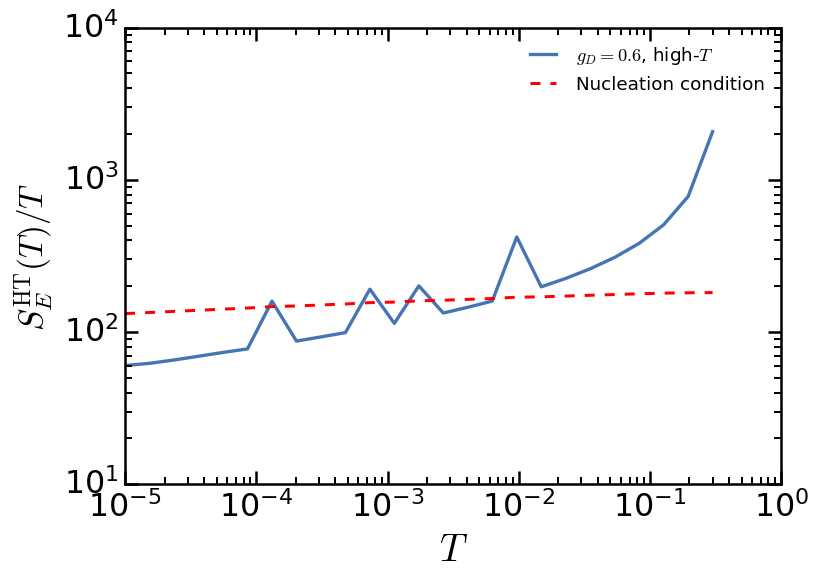

In [8]:
# Nucleation condition for high-T run
H_ht = np.array([
    fopt_obj.hubble(solver_ht.phi_min_Veff0(T, gD0_ht, scale_ht, ls0_ht), T, gD0_ht, scale_ht, ls0_ht)
    for T in T_vals_ht
])
ST_ht   = S_ht / T_vals_ht
eps     = 1e-300
nuc_rhs_ht = (4.0 * np.log(T_vals_ht)
              + 1.5 * np.log(np.maximum(ST_ht / (2.0 * np.pi), eps))
              - 4.0 * np.log(np.maximum(H_ht, eps)))
mask_ht = (np.isfinite(nuc_rhs_ht) & (nuc_rhs_ht > 0)
           & np.isfinite(ST_ht) & (ST_ht > 0))

fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')

ax.plot(T_vals_ht[np.isfinite(ST_ht)], ST_ht[np.isfinite(ST_ht)],
        color=ps.colors.get("HighT", "darkorange"), lw=2,
        label=fr'$g_D={gD0_ht}$, high-$T$')
ax.plot(T_vals_ht[mask_ht], nuc_rhs_ht[mask_ht],
        color='red', ls='--', lw=1.8, label='Nucleation condition')

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=True,
    xlabel=r'$T$',
    ylabel=r'$S_E^{\rm HT}(T)/T$',
)
ax.legend(loc='best', frameon=False, fontsize=11)
plt.tight_layout()

## 3. Generating a $(T, g_D)$ grid

A 2D grid of $\log_{10} S_E$ is the input to `FOPTUtilities` (via `SEInterpolator`). The high-$T$ solver is recommended for grid scans due to its speed.

> **Warning:** This cell is slow. With the default parameters (75 × 25 = 1875 points at ~1 min/point) it may take several hours. Reduce `n_T` and `n_gD` to test.

In [ ]:
# Grid parameters
n_T   = 75
n_gD  = 25
scale_grid = 0.25 * np.pi
ls0_grid   = 1e-10

T_grid  = np.logspace(-5, np.log10(0.35), n_T)
gD_grid = np.linspace(0.5, 1.0, n_gD)

S_log_grid = np.full((n_T, n_gD), np.nan)

for i, T in enumerate(tqdm(T_grid, desc="Temperature")):
    for j, gD in enumerate(gD_grid):
        try:
            S_val, _ = solver_ht.SE(T, gD, scale_grid, ls0_grid)
            if S_val > 0 and np.isfinite(S_val):
                S_log_grid[i, j] = np.log10(S_val)
        except Exception:
            pass   # leave as NaN

In [ ]:
# Save raw grid
np.savez(
    "../data/raw_data/SE_RGE_log_grid_HT_025piT.npz",
    S_log_grid=S_log_grid,
    T_vals=T_grid,
    gD_vals=gD_grid,
)
print(f"Grid shape: {S_log_grid.shape}")
print(f"Non-NaN fraction: {np.isfinite(S_log_grid).mean():.2%}")
print("Saved: data/raw_data/SE_RGE_log_grid_HT_025piT.npz")

## Grid diagnostics

Visualise a single $g_D$ column to spot outliers (non-monotonic jumps) before saving the cleaned grid.

In [ ]:
# Load the raw grid (skip if just computed above)
data = np.load("../data/raw_data/SE_RGE_log_grid_HT_025piT.npz")
S_log_grid = data["S_log_grid"]
T_grid     = data["T_vals"]
gD_grid    = data["gD_vals"]

# Plot every gD column; use index labels to identify outlier rows
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=110)
for ax_i, j in zip(axes, [0, n_gD // 2, n_gD - 1]):
    col = S_log_grid[:, j]
    mask_col = np.isfinite(col)
    ax_i.plot(T_grid[mask_col], col[mask_col], 'o-', color='steelblue', ms=3)
    ax_i.set_xscale('log')
    ax_i.set_xlabel(r'$T$')
    ax_i.set_ylabel(r'$\log_{10}(S_E)$')
    ax_i.set_title(fr'$g_D = {gD_grid[j]:.3f}$')
    # Annotate point indices for manual outlier identification
    for i, (T, logS) in enumerate(zip(T_grid, col)):
        if np.isfinite(logS):
            ax_i.text(T, logS + 0.04, str(i), fontsize=6, ha='center', color='crimson')
plt.tight_layout()

In [ ]:
# Remove individual outlier points identified above
# Set S_log_grid[row_index, col_index] = np.nan for each outlier
# Example (replace with actual indices from the diagnostic plot):
# S_log_grid[25, 0] = np.nan

# Save cleaned grid
np.savez_compressed(
    "../data/cleaned_data/SE_RGE_log_grid_HT_025piT_cleaned.npz",
    S_log_grid=S_log_grid,
    T_vals=T_grid,
    gD_vals=gD_grid,
)
print("Saved: data/cleaned_data/SE_RGE_log_grid_HT_025piT_cleaned.npz")